In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve 


import joblib


### Load Data

In [3]:
Non_scaled=pd.read_csv('../data/Model_Training.csv')

In [4]:
Scaled=pd.read_csv('../data/Model_Training_Scaled.csv')

In [5]:
Non_scaled

,user_id,days_since_last_transaction_x,is_active,index,total_transactions,active_days,unique_merchants,days_between_first_and_last_txn,days_since_last_transaction_y,age_group_16-18,age_group_19-22,age_group_23-30,age_group_31+,most_common_payment_method_UPI,most_common_transaction_type_Education,most_common_transaction_type_Entertainment,most_common_transaction_type_Food,most_common_transaction_type_Other,most_common_transaction_type_Shopping,most_common_transaction_type_Travel
0,U000001,0,1,0.0,18.0,13.0,12.0,29.0,8.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,U000002,18,0,1.0,2.0,2.0,2.0,4.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,U000004,0,1,2.0,7.0,6.0,7.0,30.0,8.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,U000006,16,0,3.0,2.0,2.0,2.0,12.0,24.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,U000008,9,1,4.0,9.0,8.0,8.0,20.0,17.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,U499996,0,1,463303.0,19.0,14.0,15.0,30.0,8.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
463304,U499997,1,1,463304.0,14.0,11.0,13.0,28.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
463305,U499998,4,1,463305.0,11.0,11.0,7.0,26.0,12.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
463306,U499999,5,1,463306.0,6.0,6.0,5.0,24.0,13.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [6]:
Scaled

,user_id,days_since_last_transaction_x,is_active,index,total_transactions,active_days,unique_merchants,days_between_first_and_last_txn,days_since_last_transaction_y,age_group_16-18,age_group_19-22,age_group_23-30,age_group_31+,most_common_payment_method_UPI,most_common_transaction_type_Education,most_common_transaction_type_Entertainment,most_common_transaction_type_Food,most_common_transaction_type_Other,most_common_transaction_type_Shopping,most_common_transaction_type_Travel
0,U000001,-0.638045,1,0.0,0.936779,0.764484,0.559953,0.778018,-0.638045,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,U000002,1.947976,0,1.0,-1.403246,-1.465930,-1.478741,-1.890666,1.947976,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,U000004,-0.638045,1,2.0,-0.671988,-0.654870,-0.459394,0.884766,-0.638045,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,U000006,1.660641,0,3.0,-1.403246,-1.465930,-1.478741,-1.036687,1.660641,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,U000008,0.654966,1,4.0,-0.379485,-0.249341,-0.255525,-0.182708,0.654966,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,U499996,-0.638045,1,463303.0,1.083030,0.967249,1.171561,0.884766,-0.638045,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
463304,U499997,-0.494377,1,463304.0,0.351773,0.358954,0.763823,0.671271,-0.494377,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
463305,U499998,-0.063374,1,463305.0,-0.086982,0.358954,-0.459394,0.457776,-0.063374,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
463306,U499999,0.080294,1,463306.0,-0.818240,-0.654870,-0.867133,0.244281,0.080294,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


#### I have ran the model without droping anything but I gave 100% accuracy which is too good to be true, from here we can tell that there are Data leakage happens when we training the model on the data, I have found out the leakage column which are ['days_since_last_transaction_x', 'days_since_last_transaction_y'] though they not very highly corelated with the target but may be this provide data from the future, which your model shouldn’t have access to at training time or may be keeping both can duplicate information or bring unintended leakage depending (but i checked this is not the case) better we drop it .

In [7]:
leakage_cols = ['days_since_last_transaction_x', 'days_since_last_transaction_y']
Scaled = Scaled.drop(columns=leakage_cols)
Non_scaled=Non_scaled.drop(columns=leakage_cols)

In [8]:
Non_scaled.columns.to_list()

['user_id',
 'is_active',
 'index',
 'total_transactions',
 'active_days',
 'unique_merchants',
 'days_between_first_and_last_txn',
 'age_group_16-18',
 'age_group_19-22',
 'age_group_23-30',
 'age_group_31+',
 'most_common_payment_method_UPI',
 'most_common_transaction_type_Education',
 'most_common_transaction_type_Entertainment',
 'most_common_transaction_type_Food',
 'most_common_transaction_type_Other',
 'most_common_transaction_type_Shopping',
 'most_common_transaction_type_Travel']

In [9]:
Non_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463308 entries, 0 to 463307
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   user_id                                     463308 non-null  object 
 1   is_active                                   463308 non-null  int64  
 2   index                                       463308 non-null  float64
 3   total_transactions                          463308 non-null  float64
 4   active_days                                 463308 non-null  float64
 5   unique_merchants                            463308 non-null  float64
 6   days_between_first_and_last_txn             463308 non-null  float64
 7   age_group_16-18                             463308 non-null  float64
 8   age_group_19-22                             463308 non-null  float64
 9   age_group_23-30                             463308 non-null  float64
 

## Test/Train Split

In [10]:
X_non_scaled = Non_scaled.drop(columns=['is_active','user_id', 'index'])
y = Non_scaled['is_active']

X_scaled = Scaled.drop(columns=['is_active','user_id', 'index'])
y_scaled = Scaled['is_active']

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X_non_scaled, y, test_size=0.4, random_state=52)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y_scaled, test_size=0.4, random_state=92)

#### As we have mention in the pervious notebook this is the case of imbalance dataset, better we tackel that here, For that i have used the most famous technique SMOTE which is a kind of oversampling technique.

In [11]:
smote_ns = SMOTE(random_state=50)
X_train_ns_smote, y_train_ns_smote = smote_ns.fit_resample(X_train_ns, y_train_ns)

smote_s = SMOTE(random_state=50)
X_train_s_smote, y_train_s_smote = smote_s.fit_resample(X_train_s, y_train_s)

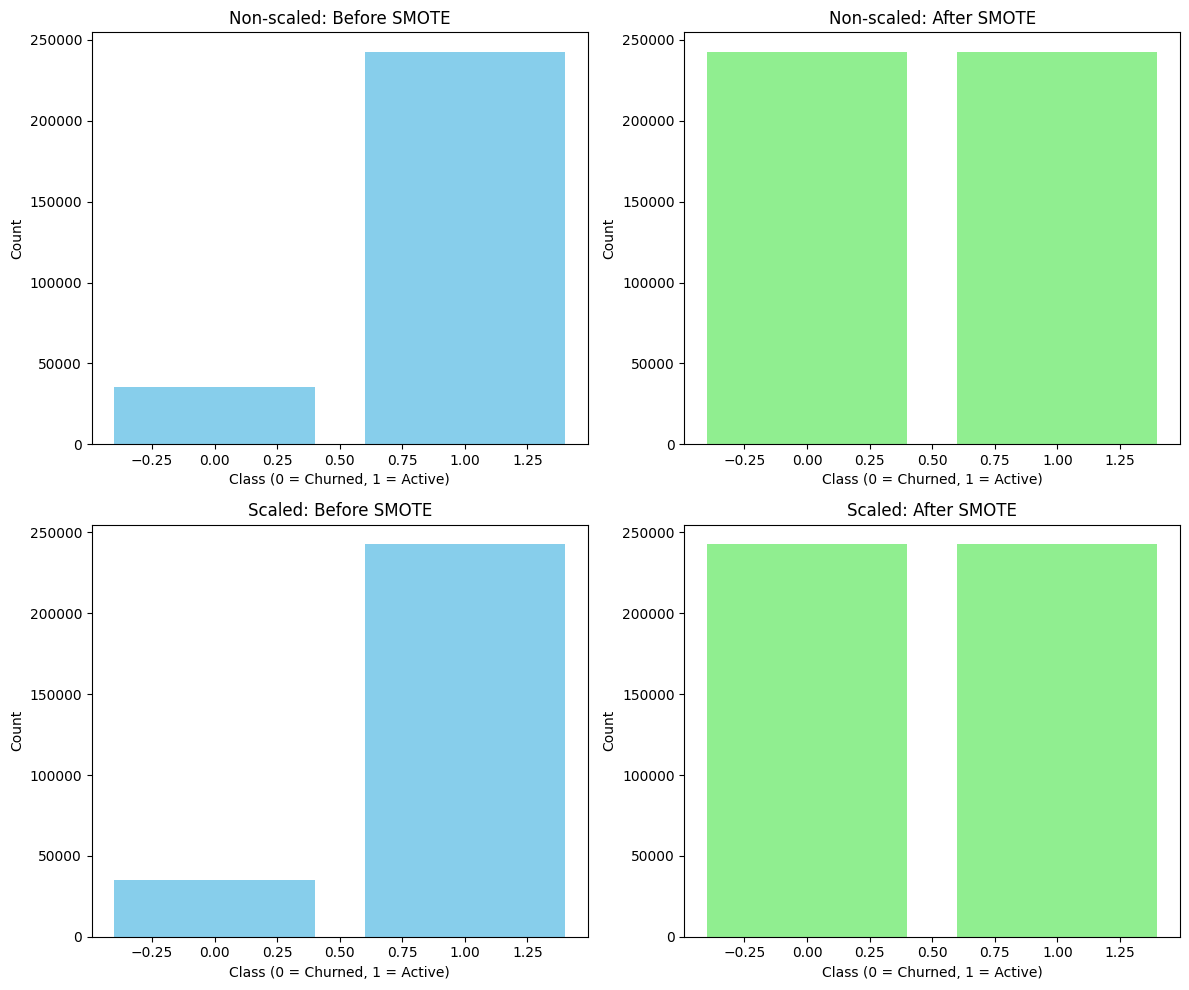

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))


axs[0, 0].bar(Counter(y_train_ns).keys(), Counter(y_train_ns).values(), color='skyblue')
axs[0, 0].set_title("Non-scaled: Before SMOTE")
axs[0, 0].set_xlabel("Class (0 = Churned, 1 = Active)")
axs[0, 0].set_ylabel("Count")

axs[0, 1].bar(Counter(y_train_ns_smote).keys(), Counter(y_train_ns_smote).values(), color='lightgreen')
axs[0, 1].set_title("Non-scaled: After SMOTE")
axs[0, 1].set_xlabel("Class (0 = Churned, 1 = Active)")
axs[0, 1].set_ylabel("Count")


axs[1, 0].bar(Counter(y_train_s).keys(), Counter(y_train_s).values(), color='skyblue')
axs[1, 0].set_title("Scaled: Before SMOTE")
axs[1, 0].set_xlabel("Class (0 = Churned, 1 = Active)")
axs[1, 0].set_ylabel("Count")


axs[1, 1].bar(Counter(y_train_s_smote).keys(), Counter(y_train_s_smote).values(), color='lightgreen')
axs[1, 1].set_title("Scaled: After SMOTE")
axs[1, 1].set_xlabel("Class (0 = Churned, 1 = Active)")
axs[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Lets train some model now

In [13]:
lr = LogisticRegression(
    penalty='l2',              
    solver='lbfgs',            
    C=1.0,                     
    max_iter=1000,             
    class_weight='balanced',  
    random_state=42          
)
lr.fit(X_train_s, y_train_s)
y_pred_lr = lr.predict(X_test_s)
y_proba_lr = lr.predict_proba(X_test_s)[:, 1]


In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_ns, y_train_ns)
y_pred_rf = rf.predict(X_test_ns)
y_proba_rf = rf.predict_proba(X_test_ns)[:, 1]


In [15]:
xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1,
        scale_pos_weight=3,  
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
)



xgb.fit(X_train_ns, y_train_ns)


c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [01:10:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [16]:
y_pred_xgb = xgb.predict(X_test_ns)
y_proba_xgb = xgb.predict_proba(X_test_ns)[:, 1]

In [17]:
print("--- Logistic Regression ---")
print(classification_report(y_test_s, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test_s, y_proba_lr))
print("\n")
print("--- Random Forest ---")
print(classification_report(y_test_ns, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test_ns, y_proba_rf))
print("\n")
print("--- XGBoost ---")
print(classification_report(y_test_ns, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test_ns, y_proba_xgb))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.74      0.98      0.84     23447
           1       1.00      0.95      0.97    161877

    accuracy                           0.95    185324
   macro avg       0.87      0.96      0.91    185324
weighted avg       0.96      0.95      0.96    185324

ROC AUC: 0.9880925206035105


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     23453
           1       1.00      0.96      0.98    161871

    accuracy                           0.96    185324
   macro avg       0.88      0.97      0.92    185324
weighted avg       0.97      0.96      0.96    185324

ROC AUC: 0.9922856178927175


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     23453
           1       0.99      0.99      0.99    161871

    accuracy                           0.98    185324
  

- We can see all model gave the good Accuracy ,ROC AUC.
- for class =1 (churn ) -> Precision (Churn),Recall (Churn) and F1 (Churn) all are good.
- Since, XGBoost better results here so use XGBoost as our primary model

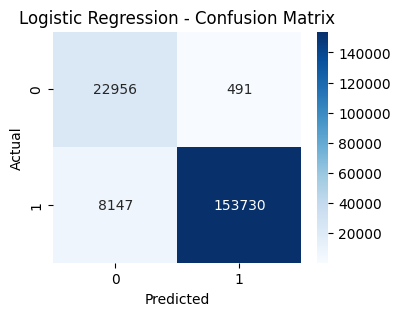

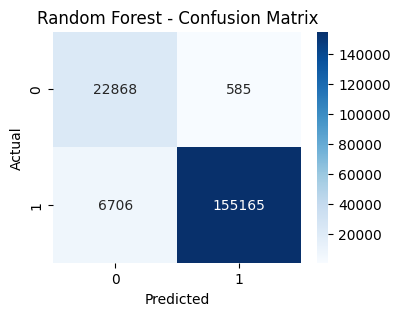

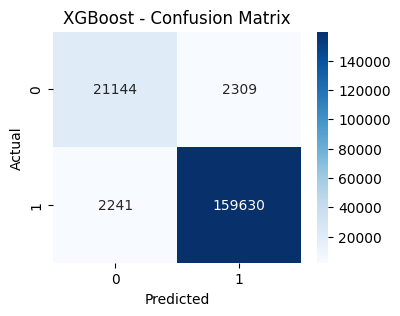

In [18]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_conf_matrix(y_test_s, y_pred_lr, "Logistic Regression")
plot_conf_matrix(y_test_ns, y_pred_rf, "Random Forest")
plot_conf_matrix(y_test_ns, y_pred_xgb, "XGBoost")


#### Hyperparameter Tuning on XGBoost

### Here I am prioritize Recall so we catch all churners, even with some false positives (it depends on bussiness to bussiness)

In [19]:
recall_churn = make_scorer(recall_score, pos_label=0) 

In [20]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 3, 5],
    'scale_pos_weight': [1, 3, 5]  
}


In [21]:
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    scoring=recall_churn,
    cv=3,
    verbose=1,
    n_jobs=-1,
    n_iter=100, 
    random_state=42
)

# Fit
random_search_xgb.fit(X_train_ns, y_train_ns)

# Best params
print("Best XGB Params:", random_search_xgb.best_params_)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
  File "c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\skl

Best XGB Params: {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [22]:
best_params = {
    'subsample': 0.8,
    'scale_pos_weight': 1,
    'reg_lambda': 1,
    'reg_alpha': 1,
    'n_estimators': 200,
    'min_child_weight': 3,
    'max_depth': 7,
    'learning_rate': 0.1,
    'gamma': 0,
    'colsample_bytree': 1.0
}

In [23]:
best_xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    **best_params
)


In [24]:
best_xgb_model.fit(X_train_ns, y_train_ns)

c:\Users\Abhishek\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [01:15:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [25]:
y_pred_xgbest = best_xgb_model.predict(X_test_ns) 
y_proba_xgbest = best_xgb_model.predict_proba(X_test_ns)[:, 1]
y_pred_xgbest=(y_proba_xgbest >= 0.4).astype(int)

In [26]:
print(classification_report(y_test_ns, y_pred_xgbest))
print("ROC AUC:", roc_auc_score(y_test_ns, y_proba_xgbest))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91     23453
           1       0.99      0.98      0.99    161871

    accuracy                           0.98    185324
   macro avg       0.94      0.96      0.95    185324
weighted avg       0.98      0.98      0.98    185324

ROC AUC: 0.992202753134542


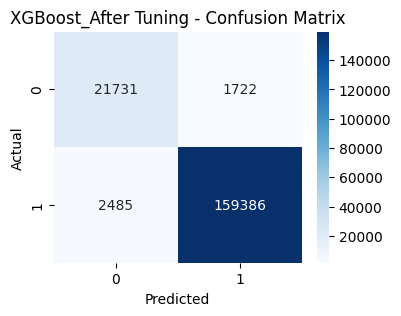

In [27]:
plot_conf_matrix(y_test_ns, y_pred_xgbest, "XGBoost_After Tuning")

### This one is better than the first one in practical terms:

    - Higher recall for class 0 (0.93 vs 0.90) ->  meaning it catches more actual class 0 cases.

    - Higher f1-score for class 0 (0.91 vs 0.90) so better balance of precision and recall.

    - Higher macro recall and macro f1-score.

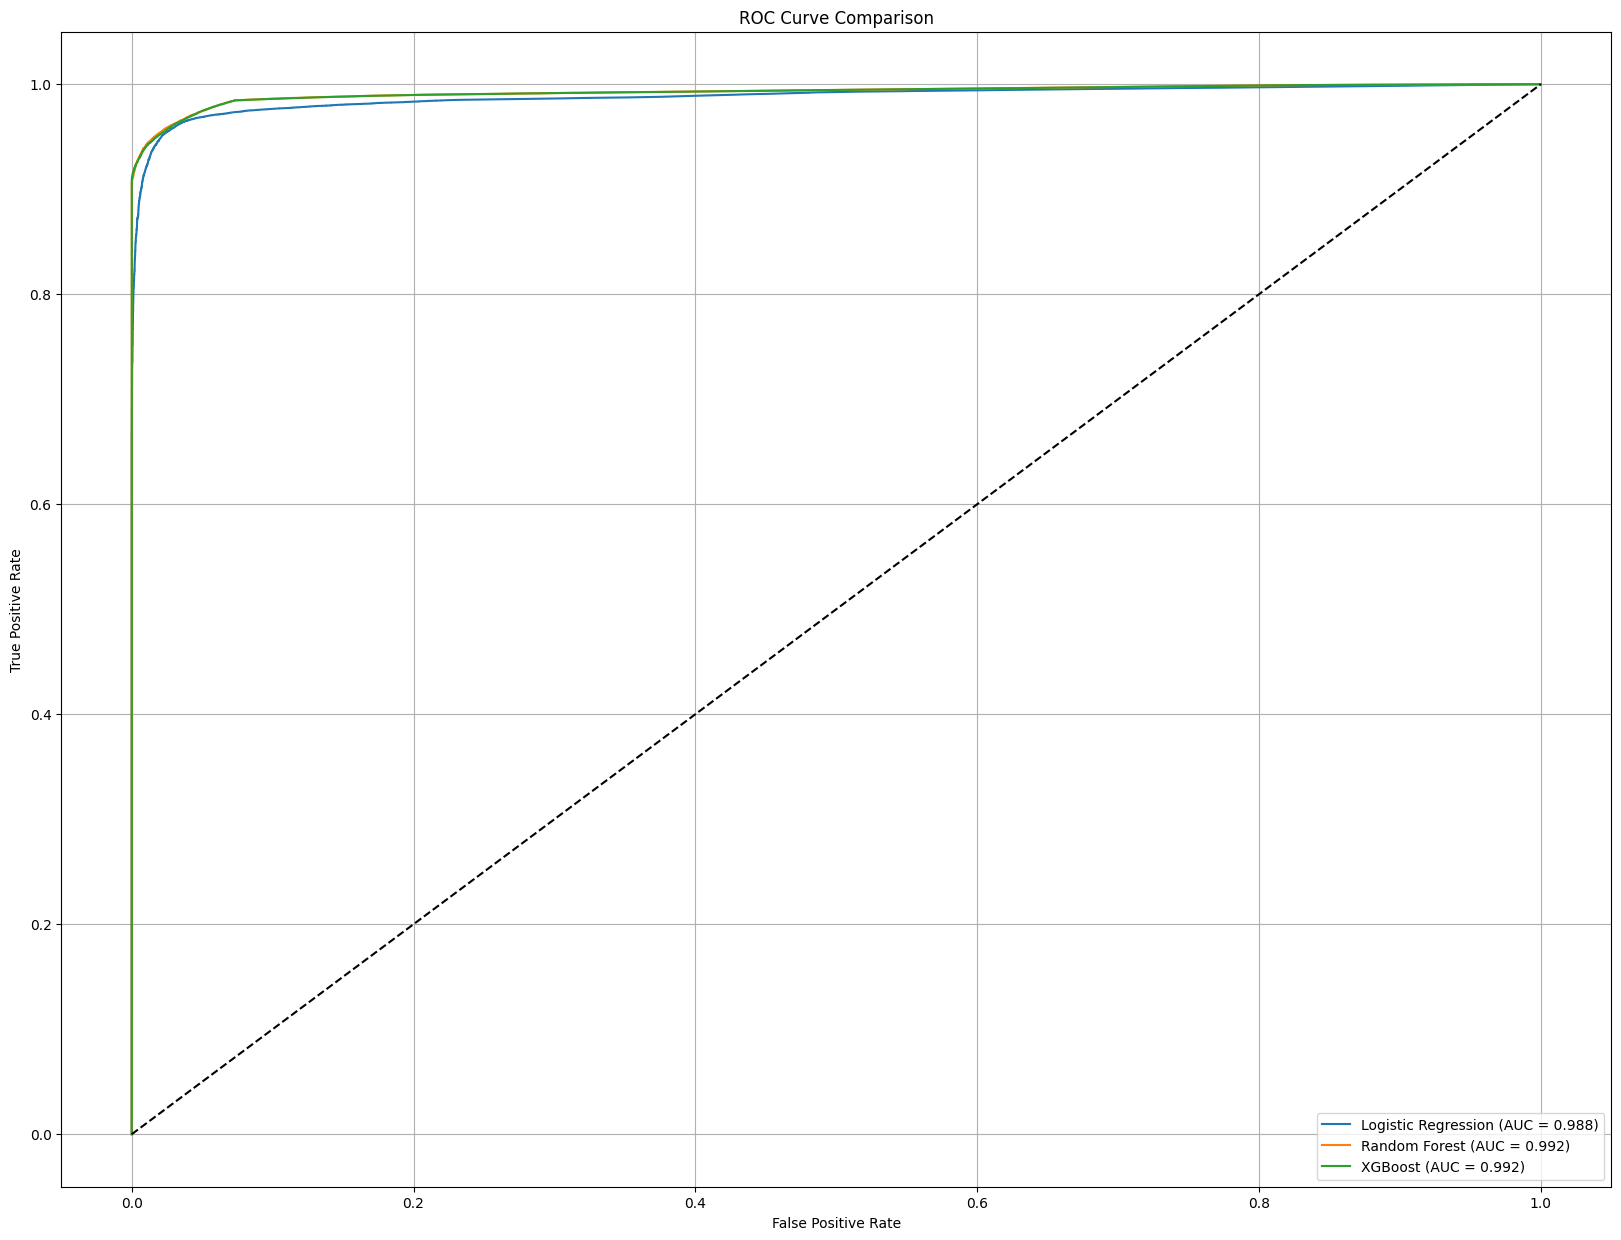

In [184]:
def plot_roc_curves(y_test_ns,y_test_s, y_proba_lr, y_proba_rf, y_proba_xgbest):

    fpr_lr, tpr_lr, _ = roc_curve(y_test_s, y_proba_lr)
    fpr_rf, tpr_rf, _ = roc_curve(y_test_ns, y_proba_rf)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test_ns, y_proba_xgbest)

    plt.figure(figsize=(20, 15))
    plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %.3f)' % roc_auc_score(y_test_s, y_proba_lr))
    plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %.3f)' % roc_auc_score(y_test_ns, y_proba_rf))
    plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %.3f)' % roc_auc_score(y_test_ns, y_proba_xgbest))
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc_curves(y_test_ns,y_test_s, y_proba_lr, y_proba_rf, y_proba_xgbest)

In [185]:
y_proba_class_0 = best_xgb_model.predict_proba(X_test_ns)[:, 0]
y_proba_class_1 = best_xgb_model.predict_proba(X_test_ns)[:, 1]

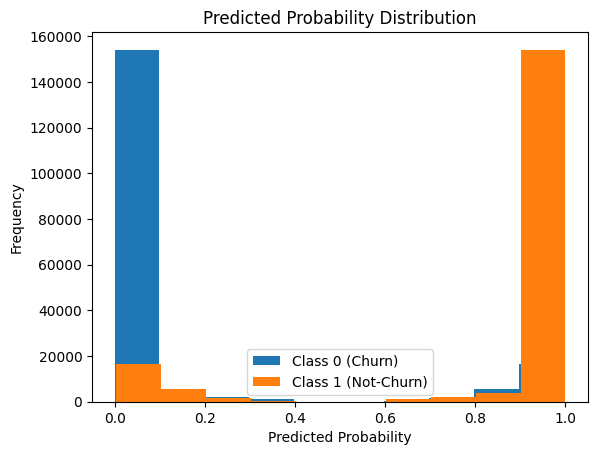

In [186]:
plt.hist(y_proba_class_0, bins=10, label='Class 0 (Churn)')
plt.hist(y_proba_class_1, bins=10, label='Class 1 (Not-Churn)')
plt.legend()
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.show()


### The model is very confident in its predictions, with very few samples predicted near the decision boundary (~0.5), Most users are confidently classified as not churners 


### There is a clear low-density gap between ~0.3 and ~0.7. This implies very little overlap, so even a middle threshold would be robust. we can safely use 0.5 as the threshold. but to optimize for specific business metrics ex. catch more churners at the cost of some false positives we could shift it for now take 0.4 to find more churn

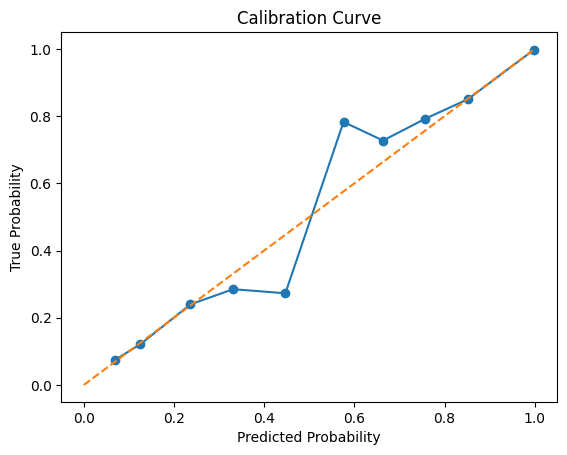

In [187]:
prob_true, prob_pred = calibration_curve(y_test_ns, best_xgb_model.predict_proba(X_test_ns)[:, 1], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.show()

### From the calibration curve checks the confidence of our model matches the reality, so model is trustworthy and no need of recalibration . Model is reasonably well-calibrated especially at the extremes (0 and 1)

### Now its better

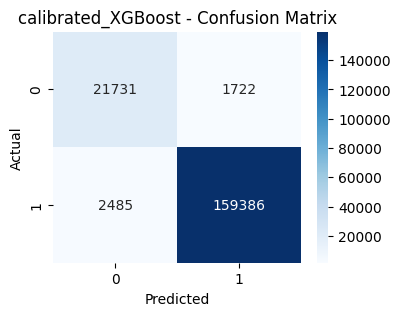

In [188]:
plot_conf_matrix(y_test_ns, y_pred_xgbest, "calibrated_XGBoost")

In [189]:
joblib.dump(best_xgb_model, '../saved_models/final_model.pkl')

['../saved_models/final_model.pkl']